In [ ]:
import pandas as pd

airbnb_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/AB_NYC_2019.csv')
attraction_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/nyc_attractions_verified.csv')
station_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/nyc-transit-subway-entrance-and-exit-data.csv')
crime_df = pd.read_csv('/Users/a2485/Desktop/프로그래머스/프로젝트 3/raw data/NYPD_Complaint_Data_Historic_20260208.csv')

In [2]:
airbnb_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
attraction_df.head()

,name,latitude,longitude,category,borough,verified_source
0,Times Square,40.7580,-73.9855,Landmark,Manhattan,Google Maps
1,Central Park,40.7829,-73.9654,Park,Manhattan,Google Maps
2,Empire State Building,40.7484,-73.9857,Observation,Manhattan,Google Maps
3,Statue of Liberty,40.6892,-74.0445,Monument,Manhattan,Google Maps
4,Brooklyn Bridge,40.7061,-73.9969,Landmark,Brooklyn,Google Maps


# 데이터 조인

## attraction

### attraction_count_2km / 3km

In [4]:
import numpy as np

# airbnb 좌표
airbnb_coords = airbnb_df[['latitude','longitude']].values

# 관광지 좌표
attraction_coords = attraction_df[['latitude','longitude']].values

In [5]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius (km)

    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2*np.arcsin(np.sqrt(a))

    return R * c

In [6]:
counts_2km = []
counts_3km = []

for lat, lon in airbnb_coords:
    
    distances = haversine(
        lat,
        lon,
        attraction_coords[:,0],
        attraction_coords[:,1]
    )
    
    count_2km = np.sum(distances <= 2)
    count_3km = np.sum(distances <= 3)
    
    counts_2km.append(count_2km)
    counts_3km.append(count_3km)

airbnb_df['attraction_count_2km'] = counts_2km
airbnb_df['attraction_count_3km'] = counts_3km

In [7]:
airbnb_df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,attraction_count_2km,attraction_count_3km
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,1,2
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,15,19
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,0,1
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,1,2
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9,1,2
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36,0,0
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27,0,1
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2,16,18


### distance_to_city_center

In [8]:
times_square_lat = 40.7580
times_square_lon = -73.9855

airbnb_df['distance_to_city_center'] = haversine(
    airbnb_df['latitude'],
    airbnb_df['longitude'],
    times_square_lat,
    times_square_lon
)

In [9]:
airbnb_df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,attraction_count_2km,attraction_count_3km,distance_to_city_center
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,1,2,12.337898
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,15,19,0.508366
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,0,1,6.757240
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,1,2,8.387034
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,0,2,5.701496
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9,1,2,9.330755
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36,0,0,7.644594
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27,0,1,7.030987
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2,16,18,0.476484


### is_manhattan

In [10]:
airbnb_df['is_manhattan'] = (airbnb_df['neighbourhood_group'] == 'Manhattan').astype(int)

In [11]:
airbnb_df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,attraction_count_2km,attraction_count_3km,distance_to_city_center,is_manhattan
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,1,2,12.337898,0
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,15,19,0.508366,1
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,0,1,6.757240,1
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,1,2,8.387034,0
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,0,2,5.701496,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9,1,2,9.330755,0
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36,0,0,7.644594,0
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27,0,1,7.030987,1
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2,16,18,0.476484,1


In [12]:
airbnb_df[['attraction_count_2km','attraction_count_3km']].describe()

,attraction_count_2km,attraction_count_3km
count,48895.000000,48895.00000
mean,3.082381,5.66197
std,4.637213,7.18233
min,0.000000,0.00000
25%,0.000000,0.00000
50%,0.000000,2.00000
75%,5.000000,13.00000
max,17.000000,21.00000


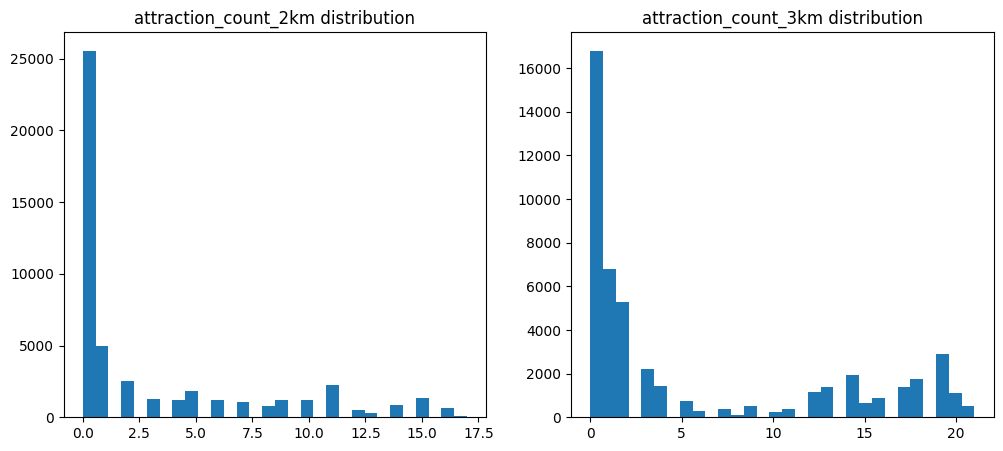

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(airbnb_df['attraction_count_2km'], bins=30)
plt.title('attraction_count_2km distribution')

plt.subplot(1,2,2)
plt.hist(airbnb_df['attraction_count_3km'], bins=30)
plt.title('attraction_count_3km distribution')

plt.show()

## station

In [14]:
station_df[station_df['Station Name'] == '34th St'][[
    'Station Name',
    'Line',
    'Division',
    'Route1',
    'Route2',
    'Route3',
    'Station Latitude',
    'Station Longitude'
]].drop_duplicates()

,Station Name,Line,Division,Route1,Route2,Route3,Station Latitude,Station Longitude
128,34th St,Broadway,BMT,B,D,F,40.749567,-73.987950
475,34th St,6 Avenue,IND,B,D,F,40.749719,-73.987823
643,34th St,8 Avenue,IND,A,C,E,40.752287,-73.993391
1247,34th St,Broadway-7th Ave,IRT,1,2,3,40.750373,-73.991057


#### station dataset을 feature engineering용으로 정리

In [15]:
# station dataset을 feature engineering용으로 정리
station_df = station_df[['Station Name','Station Latitude','Station Longitude']].drop_duplicates()
# 'Station Name','Station Latitude','Station Longitude'을 기준으로 unique한 station 473개 dataset 저장

station_df.shape

(473, 3)

#### 지하철 좌표 배열 만들기

In [16]:
station_lat = station_df['Station Latitude'].values
station_lon = station_df['Station Longitude'].values

### distance_to_nearest_station

In [17]:
nearest_dist = []

for _, row in airbnb_df.iterrows():

    dist = haversine(
        row['latitude'],
        row['longitude'],
        station_lat,
        station_lon
    )

    nearest_dist.append(dist.min())

airbnb_df['distance_to_nearest_station'] = nearest_dist

In [18]:
airbnb_df[['latitude','longitude','distance_to_nearest_station']].head()

,latitude,longitude,distance_to_nearest_station
0,40.64749,-73.97237,0.465364
1,40.75362,-73.98377,0.094923
2,40.80902,-73.94190,0.333712
3,40.68514,-73.95976,0.415913
4,40.79851,-73.94399,0.200187


각 숙소마다 가장 가까운 지하철까지의 거리(km)


*   0.094923 → 약 95m
*   0.465364 → 약 465m

In [19]:
airbnb_df['distance_to_nearest_station'].describe()

count    48895.000000
mean         0.477148
std          0.844075
min          0.000906
25%          0.204612
50%          0.318758
75%          0.478614
max         21.986269
Name: distance_to_nearest_station, dtype: float64

distance_to_nearest_station의 분포를 히스토그램으로 시각화하여 숙소의 지하철 접근성 분포를 확인하였다. 대부분의 숙소는 약 0.2km ~ 0.5km 범위 내에 위치하며, 일부 외곽 숙소는 지하철과 거리가 크게 떨어진 outlier로 나타났다.

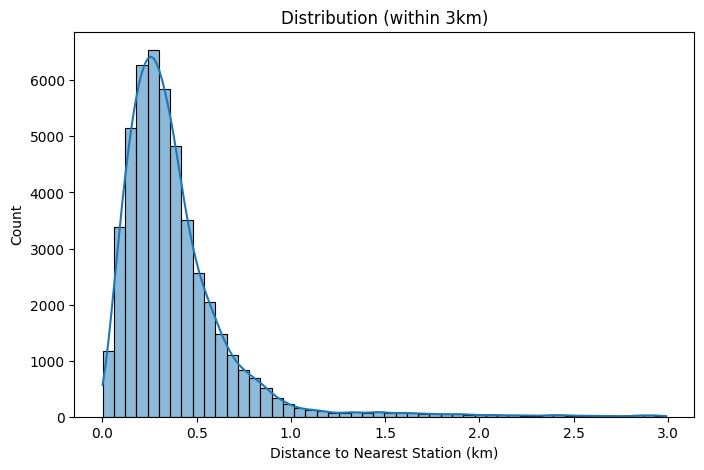

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(
    airbnb_df[airbnb_df['distance_to_nearest_station'] < 3]['distance_to_nearest_station'],
    bins=50,
    kde=True
)
plt.xlabel('Distance to Nearest Station (km)')
plt.title('Distribution (within 3km)')
plt.show()

### station_count
이미 계산한 거리 행렬을 활용해서 반경 내 역 개수 feature를 만든다

In [21]:
station_counts_300m = []
station_counts_500m = []
station_counts_1km = []

for _, row in airbnb_df.iterrows():

    dist = haversine(
        row['latitude'],
        row['longitude'],
        station_lat,
        station_lon
    )

    station_counts_300m.append((dist <= 0.3).sum())
    station_counts_500m.append((dist <= 0.5).sum())
    station_counts_1km.append((dist <= 1).sum())


airbnb_df['station_count_300m'] = station_counts_300m
airbnb_df['station_count_500m'] = station_counts_500m
airbnb_df['station_count_1km'] = station_counts_1km

In [22]:
airbnb_df[[
    'distance_to_nearest_station',
    'station_count_300m',
    'station_count_500m',
    'station_count_1km'
]].head()

,distance_to_nearest_station,station_count_300m,station_count_500m,station_count_1km
0,0.465364,0,1,4
1,0.094923,3,6,18
2,0.333712,0,1,4
3,0.415913,0,2,7
4,0.200187,1,2,6


In [23]:
airbnb_df[[
    'station_count_300m',
    'station_count_500m',
    'station_count_1km'
]].describe()

,station_count_300m,station_count_500m,station_count_1km
count,48895.000000,48895.000000,48895.000000
mean,0.647633,1.774128,6.458411
std,0.950508,1.943108,5.116016
min,0.000000,0.000000,0.000000
25%,0.000000,1.000000,3.000000
50%,0.000000,1.000000,5.000000
75%,1.000000,2.000000,8.000000
max,14.000000,21.000000,31.000000


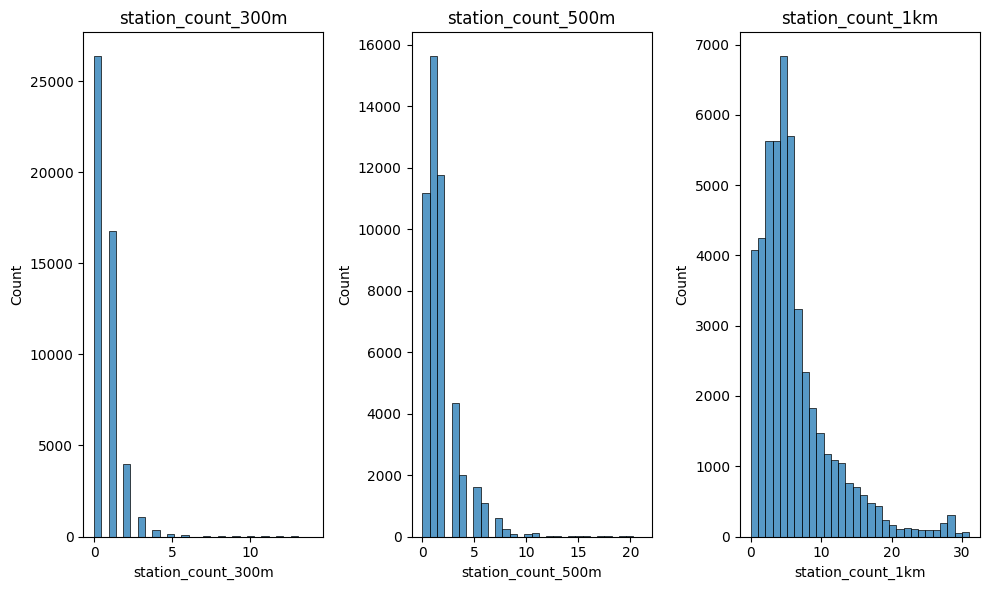

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = [
    'station_count_300m',
    'station_count_500m',
    'station_count_1km'
]

plt.figure(figsize=(10,6))

for i, col in enumerate(cols, 1):
    plt.subplot(1,3,i)
    sns.histplot(airbnb_df[col], bins=30)
    plt.title(col)

plt.tight_layout()
plt.show()

In [25]:
col = airbnb_df.pop('station_count_300m')
airbnb_df.insert(
    airbnb_df.columns.get_loc('station_count_500m'),
    'station_count_300m',
    col
)

In [26]:
airbnb_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,calculated_host_listings_count,availability_365,attraction_count_2km,attraction_count_3km,distance_to_city_center,is_manhattan,distance_to_nearest_station,station_count_300m,station_count_500m,station_count_1km
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,...,6,365,1,2,12.337898,0,0.465364,0,1,4
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,...,2,355,15,19,0.508366,1,0.094923,3,6,18
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,...,1,365,0,1,6.757240,1,0.333712,0,1,4
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,...,1,194,1,2,8.387034,0,0.415913,0,2,7
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,...,1,0,0,2,5.701496,1,0.200187,1,2,6


## crime

In [27]:
from sklearn.neighbors import BallTree
a_coords = np.radians(airbnb_df[['latitude','longitude']].values)
crime_coords = np.radians(crime_df[['Latitude','Longitude']].values)

crime_tree = BallTree(crime_coords, metric='haversine')

In [28]:
earth_radius = 6371

r05 = 0.5 / earth_radius
r1  = 1 / earth_radius
r2  = 2 / earth_radius

### crime_count

In [29]:
c05 = crime_tree.query_radius(a_coords, r=r05, count_only=True)
c1  = crime_tree.query_radius(a_coords, r=r1, count_only=True)
c2  = crime_tree.query_radius(a_coords, r=r2, count_only=True)

airbnb_df['crime_count_0.5km'] = c05
airbnb_df['crime_count_1km'] = c1
airbnb_df['crime_count_2km'] = c2

### felony_count

In [30]:
felony_df = crime_df[crime_df['LAW_CAT_CD']=='FELONY']

coords = np.radians(felony_df[['Latitude','Longitude']].values)
tree = BallTree(coords, metric='haversine')

f05 = tree.query_radius(a_coords, r=r05, count_only=True)
f1  = tree.query_radius(a_coords, r=r1, count_only=True)
f2  = tree.query_radius(a_coords, r=r2, count_only=True)

airbnb_df['felony_count_0.5km'] = f05
airbnb_df['felony_count_1km'] = f1
airbnb_df['felony_count_2km'] = f2

### misdemeanor_count

In [31]:
mis_df = crime_df[crime_df['LAW_CAT_CD']=='MISDEMEANOR']

coords = np.radians(mis_df[['Latitude','Longitude']].values)
tree = BallTree(coords, metric='haversine')

m05 = tree.query_radius(a_coords, r=r05, count_only=True)
m1  = tree.query_radius(a_coords, r=r1, count_only=True)
m2  = tree.query_radius(a_coords, r=r2, count_only=True)

airbnb_df['misdemeanor_count_0.5km'] = m05
airbnb_df['misdemeanor_count_1km'] = m1
airbnb_df['misdemeanor_count_2km'] = m2

### night_crime_count

In [32]:
crime_df['CMPLNT_FR_TM'] = pd.to_datetime(crime_df['CMPLNT_FR_TM'],format='%H:%M:%S',errors='coerce')
crime_df['hour'] = crime_df['CMPLNT_FR_TM'].dt.hour

night_df = crime_df[(crime_df['hour']>=22)|(crime_df['hour']<6)]

coords = np.radians(night_df[['Latitude','Longitude']].values)
tree = BallTree(coords, metric='haversine')

n05 = tree.query_radius(a_coords, r=r05, count_only=True)
n1  = tree.query_radius(a_coords, r=r1, count_only=True)
n2  = tree.query_radius(a_coords, r=r2, count_only=True)

airbnb_df['night_crime_count_0.5km'] = n05
airbnb_df['night_crime_count_1km'] = n1
airbnb_df['night_crime_count_2km'] = n2

### ratio 계산

In [33]:
for r in ['0.5km','1km','2km']:

    airbnb_df[f'felony_ratio_{r}'] = airbnb_df[f'felony_count_{r}'] / airbnb_df[f'crime_count_{r}']
    airbnb_df[f'misdemeanor_ratio_{r}'] = airbnb_df[f'misdemeanor_count_{r}'] / airbnb_df[f'crime_count_{r}']
    airbnb_df[f'night_crime_ratio_{r}'] = airbnb_df[f'night_crime_count_{r}'] / airbnb_df[f'crime_count_{r}']

In [34]:
pd.set_option('display.max_columns', None)

# 최종 airbnb_df

In [35]:
airbnb_df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,attraction_count_2km,attraction_count_3km,distance_to_city_center,is_manhattan,distance_to_nearest_station,station_count_300m,station_count_500m,station_count_1km,crime_count_0.5km,crime_count_1km,crime_count_2km,felony_count_0.5km,felony_count_1km,felony_count_2km,misdemeanor_count_0.5km,misdemeanor_count_1km,misdemeanor_count_2km,night_crime_count_0.5km,night_crime_count_1km,night_crime_count_2km,felony_ratio_0.5km,misdemeanor_ratio_0.5km,night_crime_ratio_0.5km,felony_ratio_1km,misdemeanor_ratio_1km,night_crime_ratio_1km,felony_ratio_2km,misdemeanor_ratio_2km,night_crime_ratio_2km
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,1,2,12.337898,0,0.465364,0,1,4,385,1856,8744,128,588,2899,179,961,4504,86,415,2117,0.332468,0.464935,0.223377,0.316810,0.517780,0.223599,0.331542,0.515096,0.242109
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,15,19,0.508366,1,0.094923,3,6,18,2407,13620,31555,853,4812,10974,1315,7522,17041,477,2575,6492,0.354383,0.546323,0.198172,0.353304,0.552276,0.189060,0.347774,0.540041,0.205736
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,0,1,6.757240,1,0.333712,0,1,4,2749,9890,30271,809,2821,8335,1549,5727,17503,461,1762,6240,0.294289,0.563478,0.167697,0.285238,0.579070,0.178160,0.275346,0.578210,0.206138
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,1,2,8.387034,0,0.415913,0,2,7,950,3944,16764,314,1369,5417,476,2010,8797,196,854,3717,0.330526,0.501053,0.206316,0.347110,0.509635,0.216531,0.323133,0.524755,0.221725
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,0,2,5.701496,1,0.200187,1,2,6,3059,10208,24907,958,2884,7054,1629,5901,14232,728,2021,5109,0.313174,0.532527,0.237986,0.282524,0.578076,0.197982,0.283214,0.571406,0.205123


In [36]:
airbnb_df.isnull().sum().loc[lambda x: x > 0]

name                          16
host_name                     21
last_review                10052
reviews_per_month          10052
felony_ratio_0.5km             5
misdemeanor_ratio_0.5km        5
night_crime_ratio_0.5km        5
dtype: int64

In [37]:
import os

output_path = '/Users/a2485/Desktop/프로그래머스/프로젝트 3'
file_path = os.path.join(output_path, 'airbnb_final.csv')

airbnb_df.to_csv(file_path, index=False, encoding='utf-8-sig')